# SMBHB Population Analysis Across Runs and Scenarios

This notebook finds and analyses saved `consistent_pop_synth` outputs across multiple runs.

It compares scenarios (optimistic/realistic/pessimistic) using:
- nearest binary distance per simulation
- loudest proxy per simulation (`max h0`)
- distributions of chirp mass, frequency, and distance

The loader is built to handle both of these formats:
1. population saved as a list of per-binary dictionaries
2. population saved as a stringified `PopulationArrays(...)` representation

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('default')
pd.set_option('display.max_columns', 50)

SCENARIOS = ('optimistic', 'realistic', 'pessimistic')

In [14]:
def infer_scenario(path: Path) -> str:
    lower_parts = [p.lower() for p in path.parts]
    for s in SCENARIOS:
        if s in lower_parts or s in path.name.lower():
            return s
    return 'unknown'


def infer_run_id(path: Path) -> str:
    date_re = re.compile(r'^\d{4}-\d{2}-\d{2}$')
    for p in path.parts:
        if date_re.match(p):
            return p
    return 'legacy'


def discover_result_files(data_root: Path = Path('data')) -> list[Path]:
    files = set()

    # Date/scenario outputs: data/YYYY-MM-DD/<scenario>/consistent_pop_synth.json
    files.update(data_root.rglob('consistent_pop_synth.json'))

    # Legacy or direct scenario outputs: data/consistent_pop_synth_<scenario>.json
    files.update(data_root.glob('consistent_pop_synth_*.json'))

    return sorted(p for p in files if p.is_file())


result_files = discover_result_files(Path('data'))
print(f'Discovered {len(result_files)} result files')
for p in result_files[::-1][:15]: # Show the most recent 15 files
    print('-', p)
if len(result_files) > 15:
    print('...')

Discovered 19 result files
- data/consistent_pop_synth_optimistic.json
- data/2026-03-31/optimistic/consistent_pop_synth.json
- data/2026-03-27/pessimistic/consistent_pop_synth.json
- data/2026-03-27/optimistic/consistent_pop_synth.json
- data/2026-03-16/optimistic/consistent_pop_synth.json
- data/2026-03-05/realistic/consistent_pop_synth.json
- data/2026-03-05/optimistic/consistent_pop_synth.json
- data/2026-03-04/optimistic/consistent_pop_synth.json
- data/2026-03-02/optimistic/consistent_pop_synth.json
- data/2026-02-26/optimistic/consistent_pop_synth.json
- data/2026-02-25/optimistic/consistent_pop_synth.json
- data/2026-02-24/optimistic/consistent_pop_synth.json
- data/2026-02-23/realistic/consistent_pop_synth.json
- data/2026-02-23/optimistic/consistent_pop_synth.json
- data/2026-02-20/realistic/consistent_pop_synth.json
...


In [3]:
def _extract_array_from_population_string(pop_text: str, key: str) -> np.ndarray | None:
    # Extract key=array([ ... ]) from stringified PopulationArrays(...) output.
    pattern = rf"{re.escape(key)}=array\(\[(.*?)\]\)"
    match = re.search(pattern, pop_text, flags=re.DOTALL)
    if not match:
        return None

    raw = match.group(1).replace('\n', ' ')
    arr = np.fromstring(raw, sep=',')
    if arr.size == 0 and raw.strip():
        # Fallback for whitespace-only separation.
        arr = np.fromstring(raw.replace(',', ' '), sep=' ')
    return arr if arr.size > 0 else None


def _population_to_arrays(population_obj) -> dict[str, np.ndarray] | None:
    if isinstance(population_obj, list):
        if not population_obj:
            return None
        out = {}
        for k in ('f', 'Mc', 'D', 'D_comov', 'h0', 'z'):
            vals = [row.get(k, np.nan) for row in population_obj]
            out[k] = np.asarray(vals, dtype=float)
        return out

    if isinstance(population_obj, str):
        out = {}
        for k in ('f', 'Mc', 'D', 'D_comov', 'h0', 'z'):
            arr = _extract_array_from_population_string(population_obj, k)
            if arr is not None:
                out[k] = arr.astype(float)
        return out if out else None

    return None


def _entry_to_binary_rows(entry: dict, source_file: Path, scenario: str, run_id: str, fallback_sim_idx: int) -> list[dict]:
    arrays = _population_to_arrays(entry.get('population'))
    if arrays is None:
        return []

    d = arrays.get('D_comov')
    if d is None:
        d = arrays.get('D')

    keys_for_len = [k for k in ('f', 'Mc', 'h0') if arrays.get(k) is not None]
    if d is not None:
        keys_for_len.append('D')

    if not keys_for_len:
        return []

    lengths = []
    for k in keys_for_len:
        if k == 'D':
            lengths.append(len(d))
        else:
            lengths.append(len(arrays[k]))

    n = int(min(lengths))
    if n == 0:
        return []

    sim_idx = entry.get('sim_index', fallback_sim_idx)
    sim_id = f"{run_id}:{sim_idx}"

    rows = []
    for i in range(n):
        rows.append({
            'scenario': scenario,
            'run_id': run_id,
            'source_file': str(source_file),
            'sim_index': int(sim_idx),
            'sim_id': sim_id,
            'binary_index': i,
            'f': float(arrays['f'][i]) if arrays.get('f') is not None else np.nan,
            'Mc': float(arrays['Mc'][i]) if arrays.get('Mc') is not None else np.nan,
            'D': float(d[i]) if d is not None else np.nan,
            'h0': float(arrays['h0'][i]) if arrays.get('h0') is not None else np.nan,
            'z': float(arrays['z'][i]) if arrays.get('z') is not None else np.nan,
        })
    return rows


def load_population_binary_table(files: list[Path]) -> pd.DataFrame:
    all_rows = []

    for fp in files:
        scenario = infer_scenario(fp)
        run_id = infer_run_id(fp)

        with fp.open('r') as f:
            payload = json.load(f)

        pops = payload.get('populations', [])
        for i, entry in enumerate(pops):
            all_rows.extend(_entry_to_binary_rows(entry, fp, scenario, run_id, i))

    if not all_rows:
        return pd.DataFrame(columns=[
            'scenario', 'run_id', 'source_file', 'sim_index', 'sim_id', 'binary_index',
            'f', 'Mc', 'D', 'h0', 'z'
        ])

    df = pd.DataFrame(all_rows)
    return df


binary_df = load_population_binary_table(result_files)
print('Binary rows:', len(binary_df))
binary_df.head()

Binary rows: 98523


,scenario,run_id,source_file,sim_index,sim_id,binary_index,f,Mc,D,h0,z
0,optimistic,2026-01-28,data/2026-01-28/optimistic/consistent_pop_synt...,0,2026-01-28:0,0,1.398871e-09,4.707364e+40,NaN,NaN,NaN
1,optimistic,2026-01-28,data/2026-01-28/optimistic/consistent_pop_synt...,0,2026-01-28:0,1,1.335913e-09,3.814319e+37,NaN,NaN,NaN
2,optimistic,2026-01-28,data/2026-01-28/optimistic/consistent_pop_synt...,0,2026-01-28:0,2,1.673201e-09,2.799844e+37,NaN,NaN,NaN
3,optimistic,2026-01-28,data/2026-01-28/optimistic/consistent_pop_synt...,0,2026-01-28:0,3,1.186925e-09,6.276487e+37,NaN,NaN,NaN
4,optimistic,2026-01-28,data/2026-01-28/optimistic/consistent_pop_synt...,0,2026-01-28:0,4,2.097650e-09,2.957934e+39,NaN,NaN,NaN


In [4]:
if binary_df.empty:
    raise RuntimeError('No binary rows loaded. Check available files and schema assumptions.')

sim_df = (
    binary_df.groupby(['scenario', 'run_id', 'source_file', 'sim_id'], as_index=False)
    .agg(
        n_binaries=('binary_index', 'count'),
        nearest_D=('D', 'min'),
        loudest_h0=('h0', 'max'),
        median_Mc=('Mc', 'median'),
        median_f=('f', 'median'),
    )
)

print('Simulations loaded:', len(sim_df))
display(sim_df.groupby('scenario', as_index=False).agg(sims=('sim_id', 'nunique'), binaries=('n_binaries', 'sum')))
display(sim_df.head())

Simulations loaded: 54


,scenario,sims,binaries
0,optimistic,49,80411
1,realistic,5,18112


,scenario,run_id,source_file,sim_id,n_binaries,nearest_D,loudest_h0,median_Mc,median_f
0,optimistic,2026-01-28,data/2026-01-28/optimistic/consistent_pop_synt...,2026-01-28:0,6000,NaN,NaN,7.805410e+37,1.366811e-09
1,optimistic,2026-02-03,data/2026-02-03/optimistic/consistent_pop_synt...,2026-02-03:0,2801,363.237728,NaN,1.376373e+38,1.384806e-09
2,optimistic,2026-02-18,data/2026-02-18/optimistic/consistent_pop_synt...,2026-02-18:0,1042,606.721659,NaN,1.556516e+38,2.500189e-09
3,optimistic,2026-02-18,data/2026-02-18/optimistic/consistent_pop_synt...,2026-02-18:1,4500,173.628461,NaN,1.494073e+38,2.549270e-09
4,optimistic,2026-02-18,data/2026-02-18/optimistic/consistent_pop_synt...,2026-02-18:2,11360,145.304231,NaN,1.537702e+38,2.571374e-09


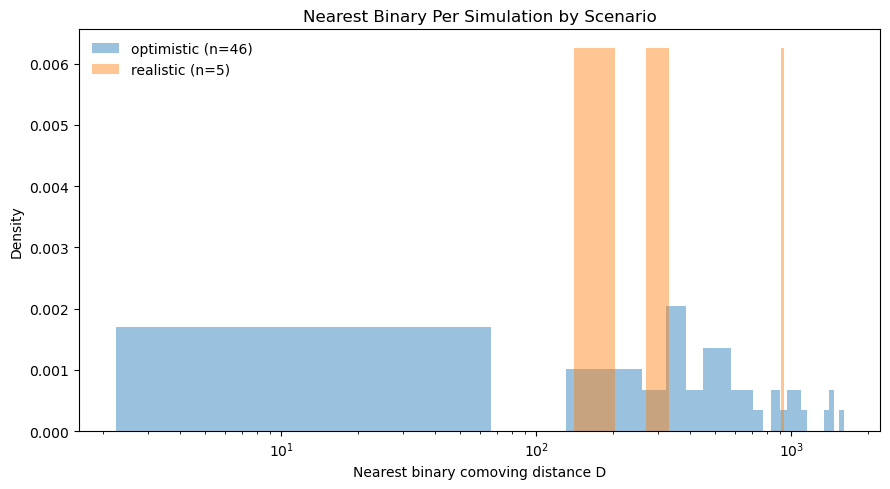

In [5]:
def hist_by_scenario(data_by_scenario: dict[str, np.ndarray], bins, xlabel: str, title: str, logx: bool = False):
    fig, ax = plt.subplots(figsize=(9, 5))
    for scenario in SCENARIOS:
        vals = data_by_scenario.get(scenario)
        if vals is None or len(vals) == 0:
            continue
        ax.hist(vals, bins=bins, alpha=0.45, density=True, label=f"{scenario} (n={len(vals)})")

    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    return fig, ax


nearest_by_scenario = {
    s: sim_df.loc[sim_df['scenario'] == s, 'nearest_D'].dropna().to_numpy()
    for s in SCENARIOS
}

_ = hist_by_scenario(
    nearest_by_scenario,
    bins=25,
    xlabel='Nearest binary comoving distance D',
    title='Nearest Binary Per Simulation by Scenario',
    logx=True,
)

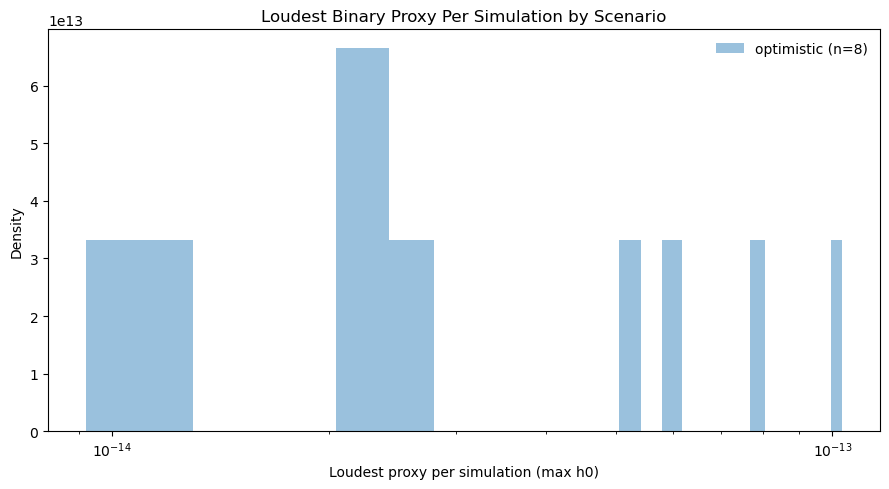

In [6]:
loudest_by_scenario = {
    s: sim_df.loc[sim_df['scenario'] == s, 'loudest_h0'].dropna().to_numpy()
    for s in SCENARIOS
}

_ = hist_by_scenario(
    loudest_by_scenario,
    bins=25,
    xlabel='Loudest proxy per simulation (max h0)',
    title='Loudest Binary Proxy Per Simulation by Scenario',
    logx=True,
)

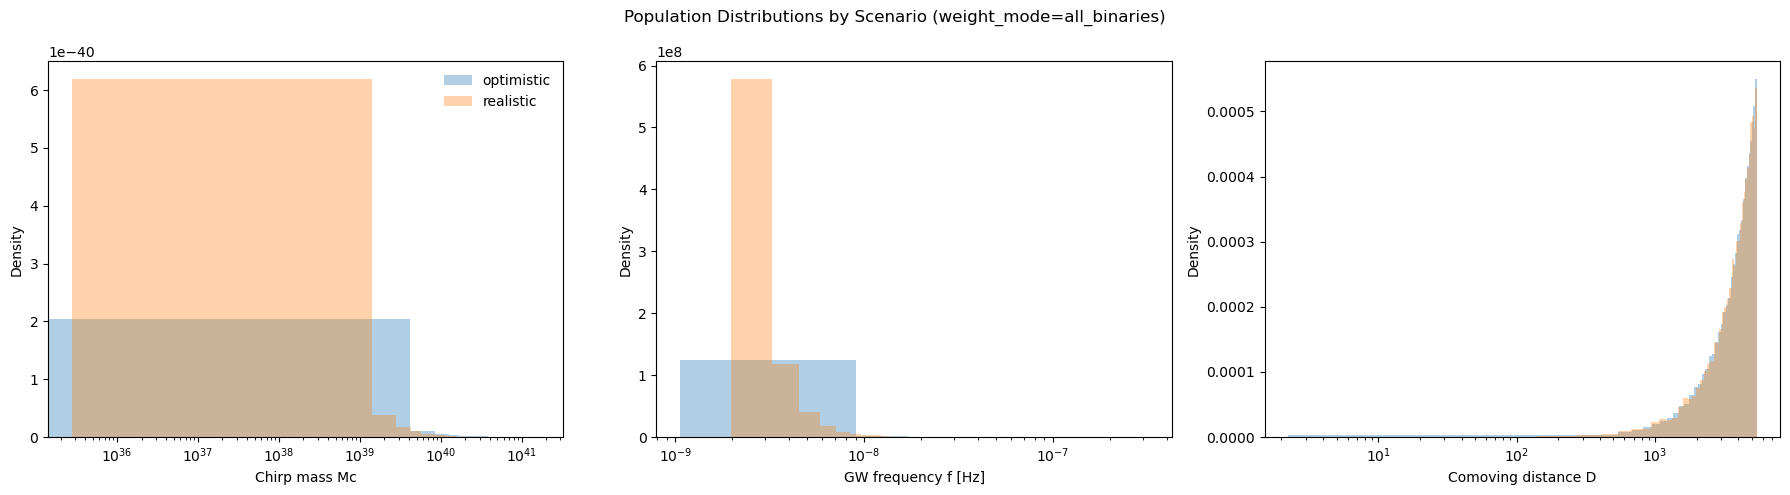

In [7]:
def add_distribution_weights(df: pd.DataFrame, mode: str = 'all_binaries') -> pd.DataFrame:
    out = df.copy()
    if mode == 'all_binaries':
        out['weight'] = 1.0
        return out

    if mode == 'per_sim_equal':
        counts = out.groupby('sim_id')['binary_index'].transform('count').astype(float)
        out['weight'] = 1.0 / counts
        return out

    raise ValueError("mode must be 'all_binaries' or 'per_sim_equal'")


weight_mode = 'all_binaries'  # change to 'per_sim_equal' if desired
dist_df = add_distribution_weights(binary_df, mode=weight_mode)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_specs = [
    ('Mc', 'Chirp mass Mc', True),
    ('f', 'GW frequency f [Hz]', True),
    ('D', 'Comoving distance D', True),
]

for ax, (col, xlabel, logx) in zip(axes, plot_specs):
    for scenario in SCENARIOS:
        sub = dist_df[(dist_df['scenario'] == scenario) & np.isfinite(dist_df[col])]
        if sub.empty:
            continue
        ax.hist(
            sub[col].to_numpy(),
            bins=40,
            weights=sub['weight'].to_numpy(),
            density=True,
            alpha=0.35,
            label=scenario,
        )

    if logx:
        ax.set_xscale('log')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')

axes[0].legend(frameon=False)
fig.suptitle(f'Population Distributions by Scenario (weight_mode={weight_mode})')
plt.tight_layout()

In [8]:
summary = (
    sim_df.groupby('scenario', as_index=False)
    .agg(
        n_sims=('sim_id', 'nunique'),
        nearest_D_median=('nearest_D', 'median'),
        nearest_D_p10=('nearest_D', lambda x: np.nanpercentile(x, 10)),
        nearest_D_p90=('nearest_D', lambda x: np.nanpercentile(x, 90)),
        loudest_h0_median=('loudest_h0', 'median'),
        loudest_h0_p10=('loudest_h0', lambda x: np.nanpercentile(x, 10)),
        loudest_h0_p90=('loudest_h0', lambda x: np.nanpercentile(x, 90)),
    )
)

summary

/opt/homebrew/anaconda3/envs/enter312/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1406: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


,scenario,n_sims,nearest_D_median,nearest_D_p10,nearest_D_p90,loudest_h0_median,loudest_h0_p10,loudest_h0_p90
0,optimistic,49,478.684707,97.904536,1088.029194,3.788945e-14,1.748094e-14,8.525337e-14
1,realistic,5,295.352452,155.184964,693.610913,NaN,NaN,NaN


## Notes on Combining Across Simulations

Default in this notebook:
- nearest/loudest metrics are per simulation (one point per sim), which is robust for scenario comparison
- distribution plots use all binaries by default (`weight_mode='all_binaries'`)

Alternative:
- set `weight_mode='per_sim_equal'` to avoid simulations with more binaries dominating parameter distributions

If you later add SNR contribution diagnostics, keep the same grouping key (`sim_id`) so all summaries stay aligned.